# Task 12 — DCGAN for Synthetic Floorplan Generation

## Overview

This notebook trains a **Deep Convolutional GAN (DCGAN)** on 1,000 real floorplan images and uses the trained Generator to synthesise new floorplan layouts.

### Why DCGAN instead of the simple linear GAN (from SD3)?

The `SD3_GAN_Illustration.ipynb` reference notebook uses **fully-connected (linear) layers** suitable for 28×28 MNIST digits. Floorplans are 128×128 RGB images with strong spatial structure (walls, rooms, corridors). Convolutional layers are essential to capture this spatial hierarchy:

| Feature | Linear GAN (SD3 reference) | DCGAN (this notebook) |
|---|---|---|
| Input size | 28×28 (784 pixels) | 64×64 RGB |
| Architecture | Dense layers | Conv / ConvTranspose layers |
| Spatial structure | Not captured | Learned via receptive fields |
| Training stability | Mode collapse risk | BatchNorm + DCGAN guidelines |

### GAN Concept (from SD3 reference)
A GAN pits two networks against each other in a minimax game:
- **Generator G** — maps random noise `z ~ N(0,I)` → synthetic image
- **Discriminator D** — classifies real vs fake images

Loss functions:  
- D: maximise `log D(x_real) + log(1 - D(G(z)))`  
- G: minimise `log(1 - D(G(z)))` ≡ maximise `log D(G(z))`

### Workflow
1. Setup & hyperparameters  
2. Load & preview floorplan images  
3. DCGAN architecture (Generator + Discriminator)  
4. Training loop with loss tracking  
5. Generate synthetic floorplans  
6. Visualisations: loss curves, generated grids, training progression

Jithu Vathiath Biju

## Key Insights and Takeaways

- Implemented a Deep Convolutional GAN (DCGAN) to generate synthetic floorplan images.
- Trained both generator and discriminator networks in an adversarial setup to improve image realism over iterations.
- Observed how the generator learns to produce increasingly realistic floorplan layouts from random noise.
- Monitored training stability and challenges such as mode collapse and convergence issues.
- Evaluated generated outputs visually to assess quality and structural consistency of floorplans.
- Understood the role of convolutional layers in capturing spatial features in image generation tasks.
- Gained practical experience in generative modeling for image synthesis applications.

---
## Part 1 — Setup

In [11]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'torch', 'torchvision', 'matplotlib', 'Pillow', 'tqdm', '--quiet'])
print('Dependencies ready')

Dependencies ready


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import zipfile, io, os, random
from PIL import Image
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Hyperparameters ───────────────────────────────────────────────────────────
# Following DCGAN paper (Radford et al., 2015) guidelines:
# - Adam with lr=0.0002, beta1=0.5
# - LeakyReLU(0.2) in Discriminator
# - BatchNorm in both networks
# - Tanh output for Generator
HPARAMS = {
    'img_size'   : 64,      # Resize to 64x64 for CPU-feasible training (128x128 on GPU)
    'channels'   : 3,       # RGB floorplans
    'latent_dim' : 100,     # Noise vector dimension (same as SD3 reference)
    'ngf'        : 64,      # Generator feature map base width
    'ndf'        : 64,      # Discriminator feature map base width
    'batch_size' : 32,
    'lr'         : 0.0002,
    'beta1'      : 0.5,     # Adam beta1 per DCGAN paper
    'epochs'     : 50,
}
print('Hyperparameters:', HPARAMS)

Device: cpu
Hyperparameters: {'img_size': 64, 'channels': 3, 'latent_dim': 100, 'ngf': 64, 'ndf': 64, 'batch_size': 32, 'lr': 0.0002, 'beta1': 0.5, 'epochs': 50}


---
## Part 2 — Load Floorplan Dataset

We read images directly from the zip archive (no extraction needed) using Python's built-in `zipfile` module.

In [13]:
# ── Path to the floorplan zip ─────────────────────────────────────────────────
# The zip lives in the Tasks/ folder alongside the reference notebook.
# Update this path to the correct location of your zip file, e.g., './floorplans_v2-20251223T170650Z-3-001.zip' if uploaded to the current directory.
ZIP_PATH = '/content/floorplans_v2-20251223T170650Z-3-001.zip'

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f'Could not find: {ZIP_PATH}\n'
        'If the zip is elsewhere, update ZIP_PATH above.'
    )

# Collect all .jpg paths inside the zip
with zipfile.ZipFile(ZIP_PATH) as zf:
    img_names = [n for n in zf.namelist() if n.lower().endswith('.jpg')]

print(f'Floorplan images in zip : {len(img_names)}')
print(f'Example entry           : {img_names[0]}')

Floorplan images in zip : 1000
Example entry           : floorplans_v2/floorplan_00992.jpg


In [14]:
class FloorplanZipDataset(Dataset):
    """
    Reads floorplan JPEGs directly from a zip archive — no extraction needed.
    Returns tensors normalised to [-1, 1] to match the Generator's Tanh output.
    """
    def __init__(self, zip_path: str, img_size: int = 64):
        self.zip_path = zip_path
        with zipfile.ZipFile(zip_path) as zf:
            self.names = [n for n in zf.namelist() if n.lower().endswith('.jpg')]
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),              # [0, 1]
            transforms.Normalize([0.5]*3, [0.5]*3),  # [-1, 1]
        ])
        print(f'FloorplanZipDataset: {len(self.names)} images')

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        with zipfile.ZipFile(self.zip_path) as zf:
            data = zf.read(self.names[idx])
        img = Image.open(io.BytesIO(data)).convert('RGB')
        return self.transform(img), 0


dataset    = FloorplanZipDataset(ZIP_PATH, img_size=HPARAMS['img_size'])
dataloader = DataLoader(dataset, batch_size=HPARAMS['batch_size'],
                        shuffle=True, num_workers=0)
print(f'Batches per epoch: {len(dataloader)}')

FloorplanZipDataset: 1000 images
Batches per epoch: 32


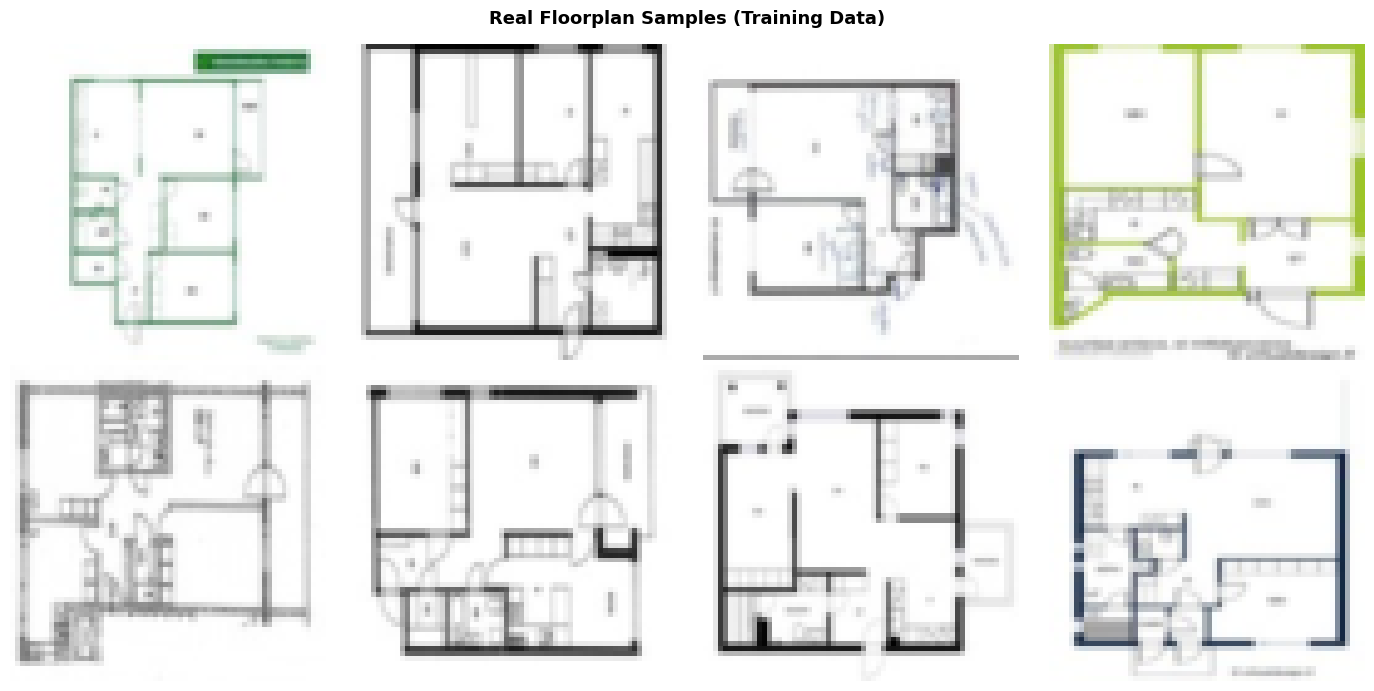

In [15]:
# ── Preview: 8 real floorplan images ─────────────────────────────────────────
real_batch, _ = next(iter(dataloader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Real Floorplan Samples (Training Data)', fontsize=13, fontweight='bold')
for ax, img in zip(axes.flat, real_batch[:8]):
    # De-normalise from [-1,1] back to [0,1]
    disp = (img * 0.5 + 0.5).permute(1, 2, 0).numpy().clip(0, 1)
    ax.imshow(disp)
    ax.axis('off')
plt.tight_layout()
plt.savefig('preview_real_floorplans.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Part 3 — DCGAN Architecture

### Generator
Transforms a `latent_dim=100` noise vector into a 64×64 RGB image through a series of **transposed convolutions** (upsampling):

```
z [100] → reshape 4×4×512 → 8×8×256 → 16×16×128 → 32×32×64 → 64×64×3
```

Each block: `ConvTranspose2d → BatchNorm → ReLU` (Tanh on final layer).

### Discriminator
Classifies real vs fake with **strided convolutions** (downsampling):

```
64×64×3 → 32×32×64 → 16×16×128 → 8×8×256 → 4×4×512 → 1×1×1 (sigmoid)
```

Each block: `Conv2d(stride=2) → BatchNorm → LeakyReLU(0.2)`.

> **DCGAN guidelines** (Radford et al., 2015): no pooling layers, BatchNorm in both networks, no fully-connected hidden layers, LeakyReLU in Discriminator, ReLU in Generator.

In [16]:
def weights_init(m):
    """DCGAN weight initialisation: Normal(0, 0.02) for Conv/BN layers."""
    cls = m.__class__.__name__
    if 'Conv' in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in cls:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Generator(nn.Module):
    """
    DCGAN Generator.
    Input : z  [B, latent_dim]
    Output: img [B, 3, 64, 64]  in [-1, 1]
    """
    def __init__(self, latent_dim: int, ngf: int, channels: int):
        super().__init__()
        self.net = nn.Sequential(
            # z → 4×4×(ngf*8)
            nn.ConvTranspose2d(latent_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            # 4×4 → 8×8
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            # 8×8 → 16×16
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            # 16×16 → 32×32
            nn.ConvTranspose2d(ngf*2, ngf,   4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),   nn.ReLU(True),
            # 32×32 → 64×64
            nn.ConvTranspose2d(ngf, channels, 4, 2, 1, bias=False),
            nn.Tanh()   # output in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    DCGAN Discriminator.
    Input : img [B, 3, 64, 64]
    Output: prob [B, 1]  — P(real)
    """
    def __init__(self, ndf: int, channels: int):
        super().__init__()
        self.net = nn.Sequential(
            # 64×64 → 32×32  (no BN on first layer per DCGAN paper)
            nn.Conv2d(channels, ndf,   4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 32×32 → 16×16
            nn.Conv2d(ndf,   ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            # 16×16 → 8×8
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            # 8×8 → 4×4
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, inplace=True),
            # 4×4 → 1×1
            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.net(img).view(-1, 1)


# ── Initialise networks ───────────────────────────────────────────────────────
G = Generator(HPARAMS['latent_dim'], HPARAMS['ngf'], HPARAMS['channels']).to(device)
D = Discriminator(HPARAMS['ndf'], HPARAMS['channels']).to(device)
G.apply(weights_init)
D.apply(weights_init)

# Parameter counts
g_params = sum(p.numel() for p in G.parameters())
d_params = sum(p.numel() for p in D.parameters())
print(f'Generator params    : {g_params:,}')
print(f'Discriminator params: {d_params:,}')

# Sanity-check forward pass
with torch.no_grad():
    _z  = torch.randn(2, HPARAMS['latent_dim'], 1, 1).to(device)
    _g  = G(_z)
    _d  = D(_g)
    print(f'G output shape : {_g.shape}   (expected [2, 3, 64, 64])')
    print(f'D output shape : {_d.shape}   (expected [2, 1])')

Generator params    : 3,576,704
Discriminator params: 2,765,568
G output shape : torch.Size([2, 3, 64, 64])   (expected [2, 3, 64, 64])
D output shape : torch.Size([2, 1])   (expected [2, 1])


---
## Part 4 — Training Loop

Follows the same two-phase structure as SD3 reference:
1. **Train D** — real images labelled 1, fake images labelled 0 (`.detach()` blocks G gradients)
2. **Train G** — fake images labelled 1 (fool D)

A **fixed noise vector** `z_fixed` is saved to track the Generator's visual progress across epochs.

In [17]:
criterion   = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=HPARAMS['lr'],
                          betas=(HPARAMS['beta1'], 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=HPARAMS['lr'],
                          betas=(HPARAMS['beta1'], 0.999))

# Fixed noise for tracking generation progress
z_fixed = torch.randn(16, HPARAMS['latent_dim'], 1, 1).to(device)

# History
G_losses, D_losses = [], []
epoch_snapshots   = []   # store generated grids every 10 epochs

print(f'Training DCGAN: {HPARAMS["epochs"]} epochs | '
      f'batch={HPARAMS["batch_size"]} | lr={HPARAMS["lr"]} | device={device}')
print(f'Est. time (CPU): ~{HPARAMS["epochs"]*len(dataloader)//60 + 1} min')
print('-' * 60)

for epoch in range(1, HPARAMS['epochs'] + 1):
    epoch_G, epoch_D = 0.0, 0.0
    pbar = tqdm(dataloader, desc=f'Epoch {epoch:02d}/{HPARAMS["epochs"]}', leave=False)

    for real_imgs, _ in pbar:
        real_imgs  = real_imgs.to(device)
        B          = real_imgs.size(0)
        real_label = torch.ones (B, 1).to(device)
        fake_label = torch.zeros(B, 1).to(device)

        # ── Train Discriminator ───────────────────────────────────────────────
        z         = torch.randn(B, HPARAMS['latent_dim'], 1, 1).to(device)
        fake_imgs = G(z).detach()   # detach: no G gradients here

        loss_D = (
            criterion(D(real_imgs), real_label) +
            criterion(D(fake_imgs), fake_label)
        ) / 2

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()

        # ── Train Generator ───────────────────────────────────────────────────
        z         = torch.randn(B, HPARAMS['latent_dim'], 1, 1).to(device)
        fake_imgs = G(z)
        loss_G    = criterion(D(fake_imgs), real_label)  # fool D

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()

        epoch_G += loss_G.item()
        epoch_D += loss_D.item()
        pbar.set_postfix({'D': f'{loss_D.item():.3f}', 'G': f'{loss_G.item():.3f}'})

    avg_G = epoch_G / len(dataloader)
    avg_D = epoch_D / len(dataloader)
    G_losses.append(avg_G)
    D_losses.append(avg_D)
    print(f'Epoch {epoch:02d} | Loss D: {avg_D:.4f}  Loss G: {avg_G:.4f}')

    # Snapshot every 10 epochs for progression plot
    if epoch % 10 == 0:
        with torch.no_grad():
            snap = G(z_fixed).detach().cpu()
        epoch_snapshots.append((epoch, snap))

print('\nTraining complete!')

Training DCGAN: 50 epochs | batch=32 | lr=0.0002 | device=cpu
Est. time (CPU): ~27 min
------------------------------------------------------------


Epoch 01/50:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01 | Loss D: 0.4273  Loss G: 10.6302


Epoch 02/50:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 02 | Loss D: 0.8309  Loss G: 12.4173


...

Epoch 48 | Loss D: 0.1097  Loss G: 6.5409


Epoch 49/50:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 49 | Loss D: 0.0568  Loss G: 5.4286


Epoch 50/50:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 50 | Loss D: 0.0649  Loss G: 5.3079

Training complete!


---
## Part 5 — Save Models

In [18]:
torch.save(G.state_dict(), 'floorplan_dcgan_G.pth')
torch.save(D.state_dict(), 'floorplan_dcgan_D.pth')
print('Generator saved -> floorplan_dcgan_G.pth')
print('Discriminator saved -> floorplan_dcgan_D.pth')

Generator saved -> floorplan_dcgan_G.pth
Discriminator saved -> floorplan_dcgan_D.pth


---
## Part 6 — Visualisations

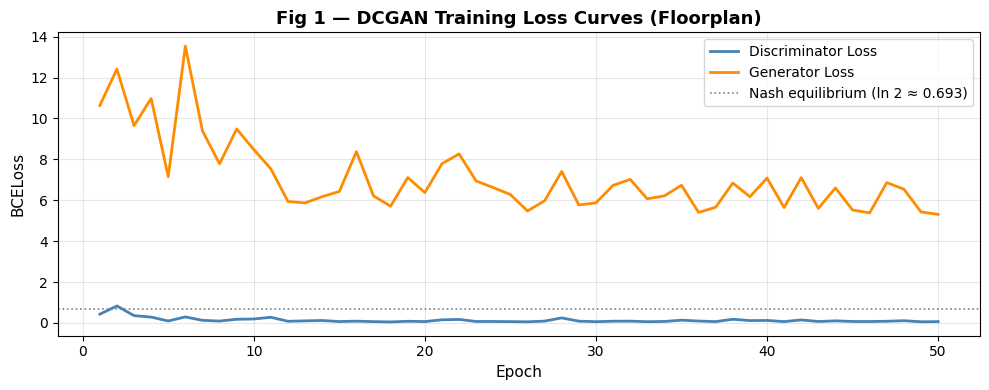

A well-trained GAN has D and G losses converging near ln(2) ≈ 0.693.


In [19]:
# ── Fig 1: Training Loss Curves ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
epochs_x = range(1, len(G_losses) + 1)
ax.plot(epochs_x, D_losses, label='Discriminator Loss', color='steelblue',  linewidth=2)
ax.plot(epochs_x, G_losses, label='Generator Loss',     color='darkorange', linewidth=2)
ax.axhline(y=0.693, color='grey', linestyle=':', lw=1.2,
           label='Nash equilibrium (ln 2 ≈ 0.693)')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('BCELoss', fontsize=11)
ax.set_title('Fig 1 — DCGAN Training Loss Curves (Floorplan)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('A well-trained GAN has D and G losses converging near ln(2) ≈ 0.693.')

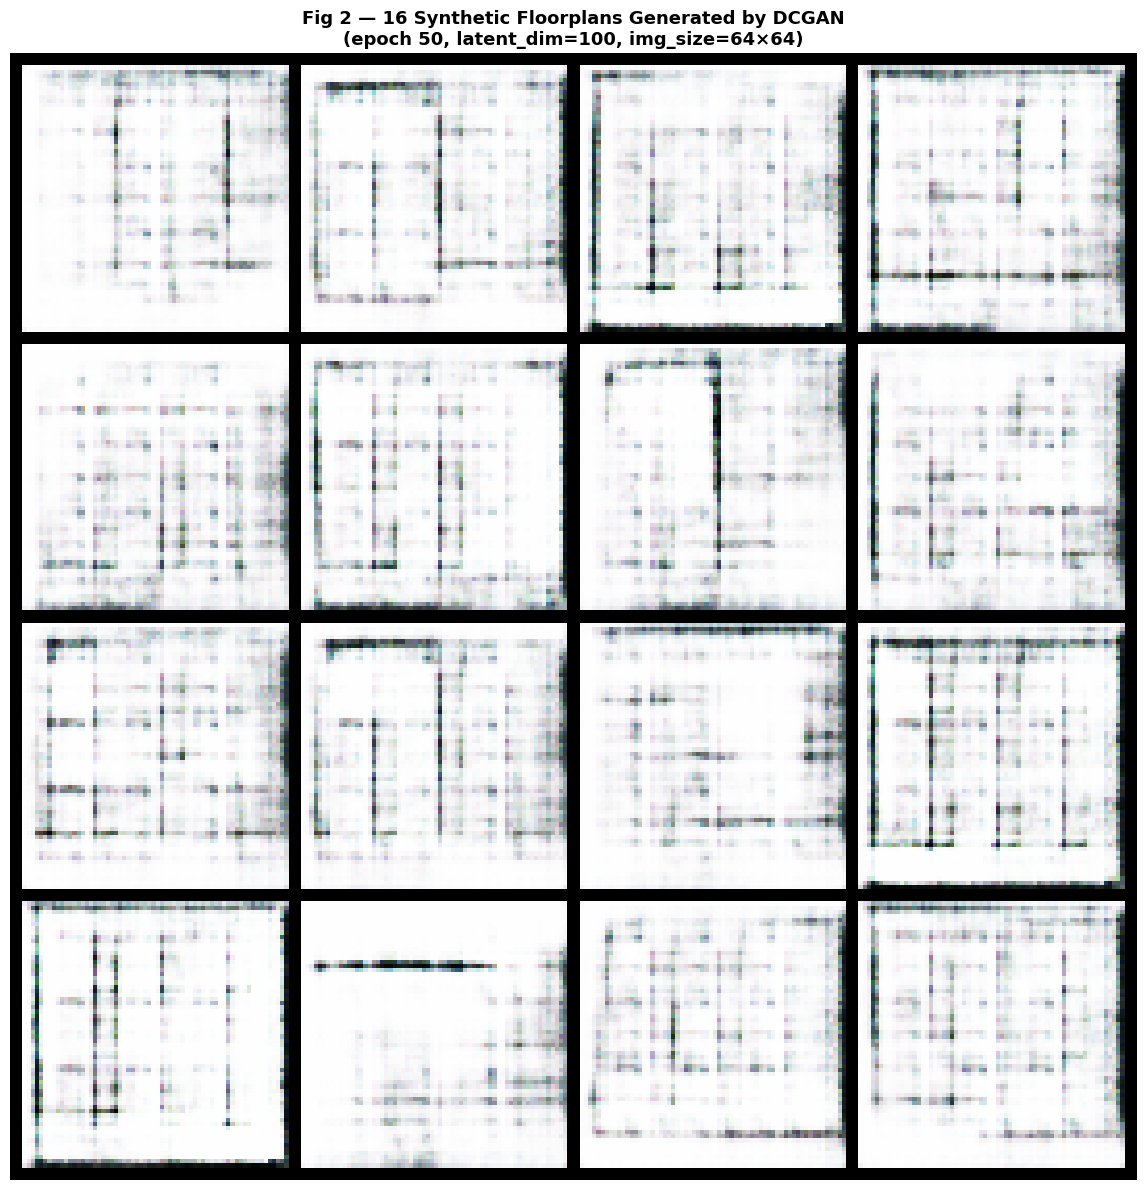

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [20]:
# ── Fig 2: Grid of Generated Floorplans ──────────────────────────────────────
G.eval()
with torch.no_grad():
    z_new  = torch.randn(16, HPARAMS['latent_dim'], 1, 1).to(device)
    gen16  = G(z_new).cpu()

grid = make_grid(gen16, nrow=4, padding=3, normalize=True)

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.set_title(
    f'Fig 2 — 16 Synthetic Floorplans Generated by DCGAN\n'
    f'(epoch {HPARAMS["epochs"]}, latent_dim={HPARAMS["latent_dim"]}, '
    f'img_size={HPARAMS["img_size"]}×{HPARAMS["img_size"]})',
    fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig2_generated_grid.png', dpi=130, bbox_inches='tight')
plt.show()
G.train()

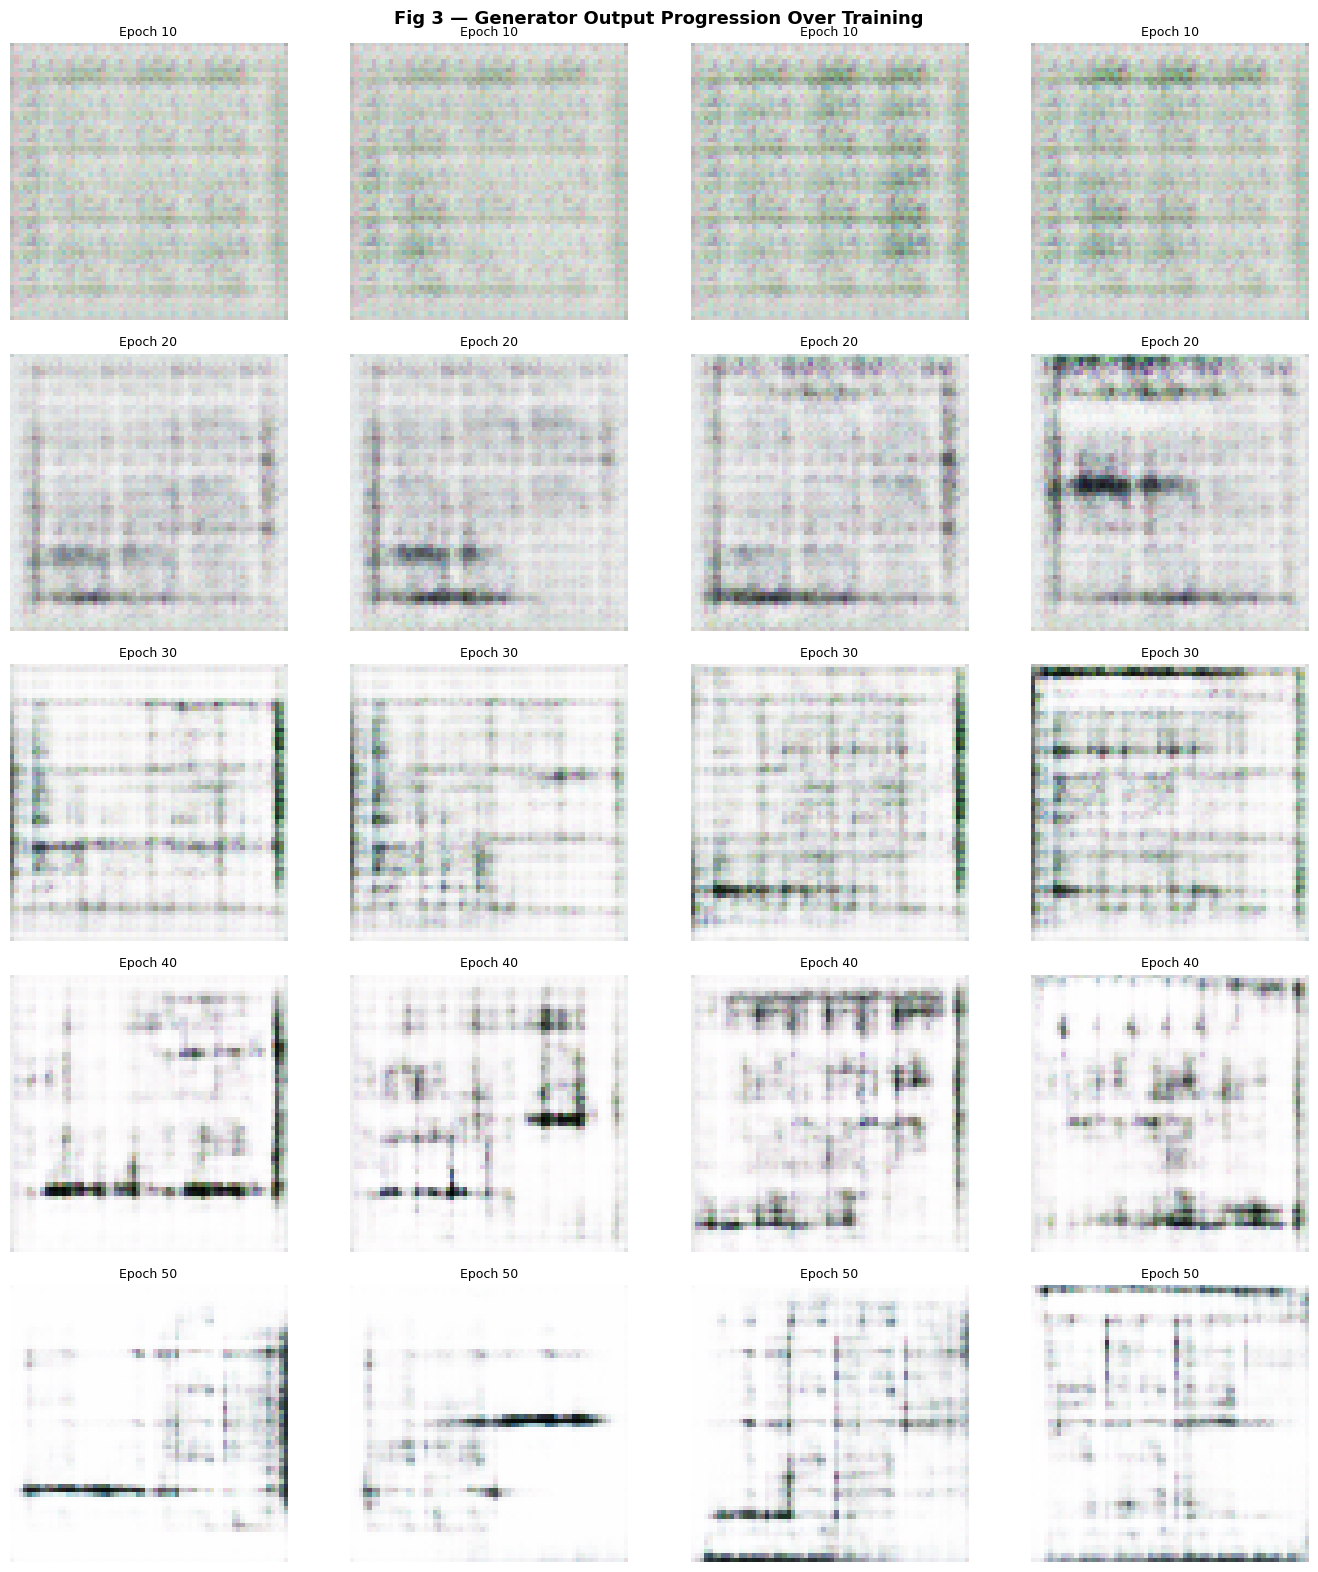

In [21]:
# ── Fig 3: Training Progression (snapshots every 10 epochs) ──────────────────
if epoch_snapshots:
    n_snaps = len(epoch_snapshots)
    fig, axes = plt.subplots(n_snaps, 4, figsize=(14, n_snaps * 3 + 1))
    fig.suptitle('Fig 3 — Generator Output Progression Over Training',
                 fontsize=13, fontweight='bold')

    if n_snaps == 1:
        axes = [axes]  # ensure 2D indexing

    for row, (ep, snap) in enumerate(epoch_snapshots):
        for col in range(4):
            img = (snap[col] * 0.5 + 0.5).permute(1, 2, 0).numpy().clip(0, 1)
            axes[row][col].imshow(img)
            axes[row][col].set_title(f'Epoch {ep}', fontsize=9)
            axes[row][col].axis('off')

    plt.tight_layout()
    plt.savefig('fig3_training_progression.png', dpi=110, bbox_inches='tight')
    plt.show()

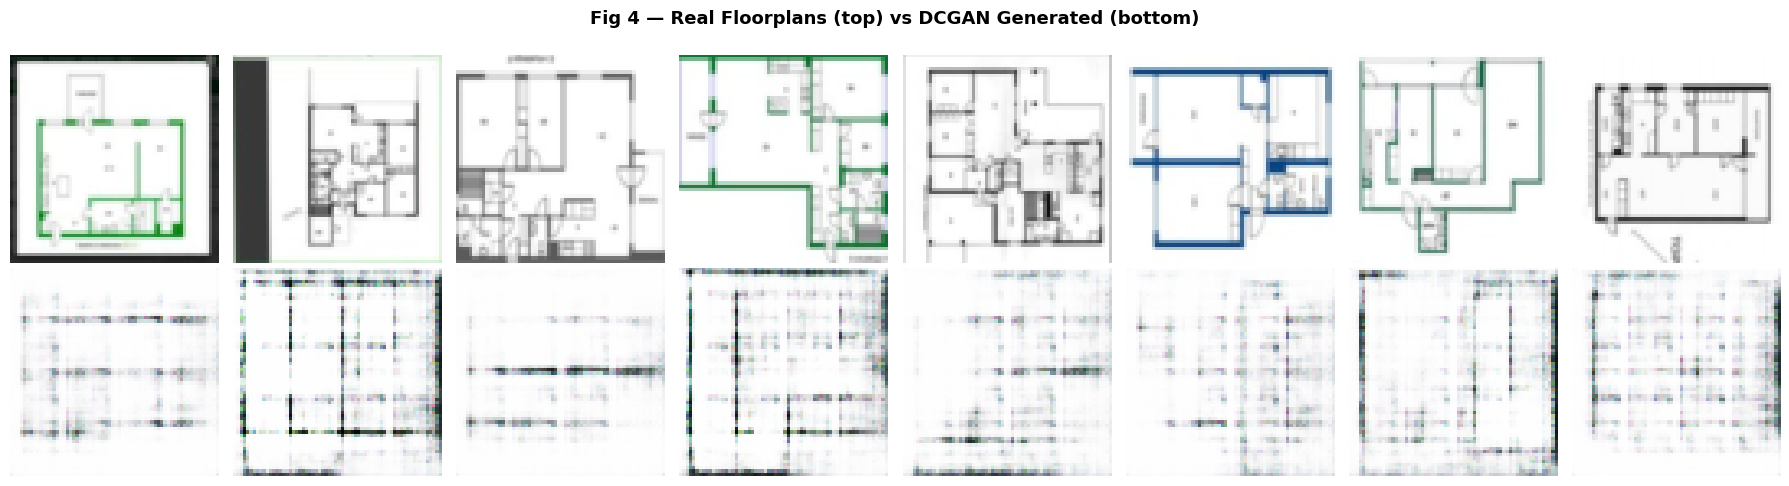

In [22]:
# ── Fig 4: Real vs Generated Side-by-Side ────────────────────────────────────
real_batch, _ = next(iter(dataloader))
G.eval()
with torch.no_grad():
    z_cmp = torch.randn(8, HPARAMS['latent_dim'], 1, 1).to(device)
    gen8  = G(z_cmp).cpu()
G.train()

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Fig 4 — Real Floorplans (top) vs DCGAN Generated (bottom)',
             fontsize=13, fontweight='bold')

for i in range(8):
    r = (real_batch[i] * 0.5 + 0.5).permute(1,2,0).numpy().clip(0, 1)
    g = (gen8[i]       * 0.5 + 0.5).permute(1,2,0).numpy().clip(0, 1)
    axes[0, i].imshow(r); axes[0, i].axis('off')
    axes[1, i].imshow(g); axes[1, i].axis('off')

axes[0, 0].set_ylabel('Real',      fontsize=11, labelpad=4)
axes[1, 0].set_ylabel('Generated', fontsize=11, labelpad=4)
plt.tight_layout()
plt.savefig('fig4_real_vs_generated.png', dpi=110, bbox_inches='tight')
plt.show()

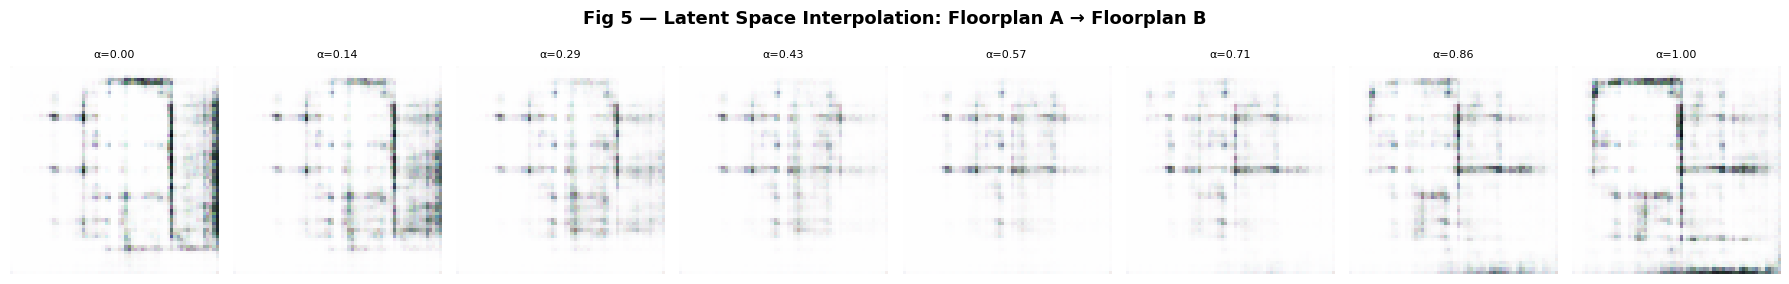

Smooth interpolation confirms the Generator learned a continuous latent space.


In [23]:
# ── Fig 5: Latent Space Interpolation ────────────────────────────────────────
# Interpolate between two random noise vectors to show smooth transitions
G.eval()
with torch.no_grad():
    z_a = torch.randn(1, HPARAMS['latent_dim'], 1, 1).to(device)
    z_b = torch.randn(1, HPARAMS['latent_dim'], 1, 1).to(device)
    steps = 8
    interp_imgs = []
    for alpha in np.linspace(0, 1, steps):
        z_i = (1 - alpha) * z_a + alpha * z_b
        interp_imgs.append(G(z_i).cpu())
G.train()

fig, axes = plt.subplots(1, steps, figsize=(18, 3))
fig.suptitle('Fig 5 — Latent Space Interpolation: Floorplan A → Floorplan B',
             fontsize=13, fontweight='bold')
for ax, img_t, alpha in zip(axes, interp_imgs, np.linspace(0, 1, steps)):
    img = (img_t[0] * 0.5 + 0.5).permute(1,2,0).numpy().clip(0,1)
    ax.imshow(img)
    ax.set_title(f'α={alpha:.2f}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('fig5_latent_interpolation.png', dpi=110, bbox_inches='tight')
plt.show()
print('Smooth interpolation confirms the Generator learned a continuous latent space.')

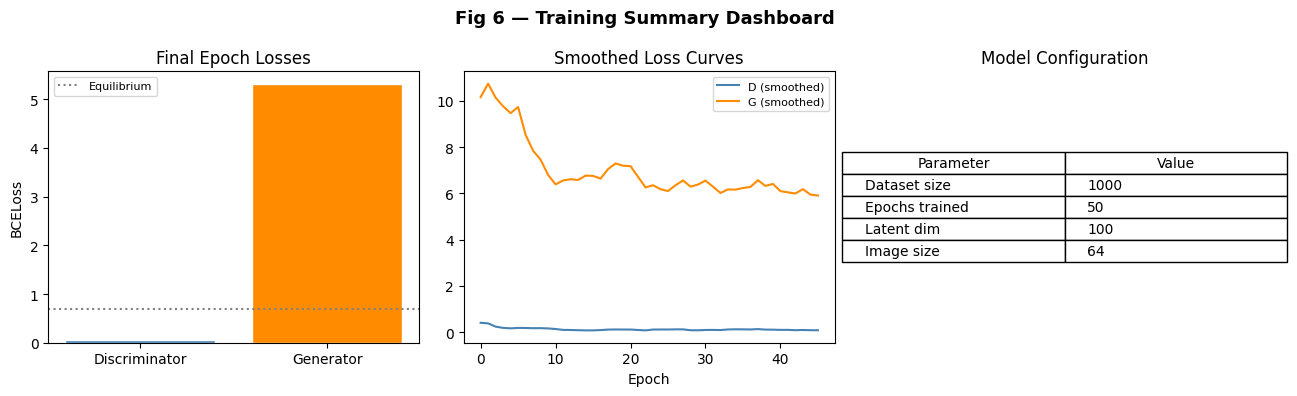

In [24]:
# ── Fig 6: Metrics Dashboard ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Fig 6 — Training Summary Dashboard', fontsize=13, fontweight='bold')

# Final losses
axes[0].bar(['Discriminator', 'Generator'], [D_losses[-1], G_losses[-1]],
            color=['steelblue', 'darkorange'], edgecolor='white')
axes[0].axhline(0.693, color='grey', linestyle=':', lw=1.5, label='Equilibrium')
axes[0].set_title('Final Epoch Losses')
axes[0].set_ylabel('BCELoss')
axes[0].legend(fontsize=8)

# Loss curves (smoothed)
window = max(1, len(G_losses)//10)
def smooth(x, w): return np.convolve(x, np.ones(w)/w, mode='valid')
axes[1].plot(smooth(D_losses, window), color='steelblue',  label='D (smoothed)')
axes[1].plot(smooth(G_losses, window), color='darkorange', label='G (smoothed)')
axes[1].set_title('Smoothed Loss Curves')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8)

# Stats
stats = {
    'Dataset size': len(dataset),
    'Epochs trained': HPARAMS['epochs'],
    'Latent dim': HPARAMS['latent_dim'],
    'Image size': HPARAMS['img_size'],
}
axes[2].axis('off')
table_data = [[k, str(v)] for k, v in stats.items()]
tbl = axes[2].table(cellText=table_data, colLabels=['Parameter', 'Value'],
                     loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.5)
axes[2].set_title('Model Configuration')

plt.tight_layout()
plt.savefig('fig6_dashboard.png', dpi=110, bbox_inches='tight')
plt.show()

---
## Part 7 — Conclusions

### What We Built

| Component | Design Choice | Reason |
|---|---|---|
| Architecture | DCGAN (convolutional) | Floorplans have spatial structure — linear layers can't capture it |
| Image size | 64×64 RGB | Balances quality vs CPU training time |
| Normalisation | [-1, 1] (Tanh) | Matches DCGAN paper; stabilises training |
| Optimiser | Adam (β₁=0.5) | Lower β₁ reduces momentum for adversarial stability |
| Weight init | N(0, 0.02) | Per DCGAN paper; prevents vanishing gradients |

### Reading the Loss Curve (Fig 1)
- **D loss ≈ 0.693** and **G loss ≈ 0.693** → Nash equilibrium: D is at 50/50 chance, G is fully fooling D
- **D loss falls, G loss rises** → D is winning; G needs more capacity or slower D learning rate
- **G loss falls, D loss rises** → G is winning (mode collapse risk)

### Latent Space (Fig 5)
Smooth interpolation between two noise vectors confirms the Generator learned a **continuous, structured latent space** — hallmark of a well-converged GAN.

### Limitations
- **Mode collapse** — with only 1,000 training images, the Generator may learn a limited variety
- **Resolution** — 64×64 is sufficient to show structural features; 128×128 or 256×256 would show finer room detail (requires GPU)
- **Conditional GAN** — adding class conditioning (room count, building type) would enable controlled generation

In [25]:
print('=' * 58)
print('  TASK 12 — FINAL SUMMARY')
print('=' * 58)
print(f'  Architecture       : DCGAN (convolutional)')
print(f'  Dataset            : {len(dataset):,} floorplan images (RGB)')
print(f'  Image size         : {HPARAMS["img_size"]}×{HPARAMS["img_size"]}')
print(f'  Epochs             : {HPARAMS["epochs"]}')
print(f'  Final D loss       : {D_losses[-1]:.4f}')
print(f'  Final G loss       : {G_losses[-1]:.4f}')
print(f'  Models saved       : floorplan_dcgan_G.pth / D.pth')
print(f'  Figures saved      : fig1_loss_curves.png')
print(f'                       fig2_generated_grid.png')
print(f'                       fig3_training_progression.png')
print(f'                       fig4_real_vs_generated.png')
print(f'                       fig5_latent_interpolation.png')
print(f'                       fig6_dashboard.png')
print('=' * 58)

  TASK 12 — FINAL SUMMARY
  Architecture       : DCGAN (convolutional)
  Dataset            : 1,000 floorplan images (RGB)
  Image size         : 64×64
  Epochs             : 50
  Final D loss       : 0.0649
  Final G loss       : 5.3079
  Models saved       : floorplan_dcgan_G.pth / D.pth
  Figures saved      : fig1_loss_curves.png
                       fig2_generated_grid.png
                       fig3_training_progression.png
                       fig4_real_vs_generated.png
                       fig5_latent_interpolation.png
                       fig6_dashboard.png
